# Task 3: Clip Tasks

1. Zero-Shot Classification on STL-10

In [1]:
# ── 0. Install CLIP ───────────────────────────────────────────────────────────

!pip install git+https://github.com/openai/CLIP.git -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────

import torch
import clip
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ── 1. Load CLIP model ────────────────────────────────────────────────────────
# ViT-B/32 is the standard CLIP model — fast and well-tested
# clip.load() returns both the model and its required image preprocessor

model_clip, preprocess_clip = clip.load("ViT-B/32", device=device)
model_clip.eval()

print(f"\nCLIP ViT-B/32 loaded")
print(f"Input resolution : {model_clip.visual.input_resolution}")
print(f"Embedding dim    : {model_clip.visual.output_dim}")
print(f"Context length   : {model_clip.context_length}")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 320MiB/s]



CLIP ViT-B/32 loaded
Input resolution : 224
Embedding dim    : 512
Context length   : 77


In [4]:
# ── 2. Load STL-10 test set ───────────────────────────────────────────────────
# IMPORTANT: use preprocess_clip as the transform — not standard ImageNet norm

stl10_test = torchvision.datasets.STL10(
    root='./data', split='test', download=True, transform=preprocess_clip
)

test_loader = DataLoader(
    stl10_test, batch_size=128, shuffle=False, num_workers=2
)

STL10_CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer',
                 'dog', 'horse', 'monkey', 'ship', 'truck']

print(f"\nSTL-10 test samples : {len(stl10_test)}")
print(f"Classes             : {STL10_CLASSES}")

100%|██████████| 2.64G/2.64G [06:30<00:00, 6.77MB/s]  



STL-10 test samples : 8000
Classes             : ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
# ── 3. Define prompting strategies ────────────────────────────────────────────
# Each strategy is a function that takes a class name and returns a prompt string

prompting_strategies = {

    "plain_label": lambda c: f"{c}",

    "photo_prompt": lambda c: f"a photo of a {c}",

    "detailed_prompt": lambda c: (
        f"a high-resolution photo of a {c}"
    ),

    "contextual_prompt": lambda c: (
        f"a picture taken in the wild of a {c}"
        if c in ['bird', 'deer', 'horse', 'monkey']
        else f"a real-world photo of a {c} in its natural setting"
    ),
}

In [6]:
# ── 4. Helper: encode text prompts ────────────────────────────────────────────

def encode_text_prompts(model, class_names, prompt_fn, device):
    """
    For each class, apply prompt_fn to get a text string,
    tokenize it, and encode it with CLIP's text encoder.
    Returns normalized text embeddings of shape (num_classes, embed_dim).
    """
    prompts = [prompt_fn(c) for c in class_names]
    print(f"  Example prompt: '{prompts[0]}'")

    tokens = clip.tokenize(prompts).to(device)   # (num_classes, context_len)
    with torch.no_grad():
        text_features = model.encode_text(tokens)   # (num_classes, embed_dim)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features

In [7]:
# ── 5. Helper: encode all images ──────────────────────────────────────────────

def encode_images(model, loader, device):
    """
    Run all images through CLIP's image encoder.
    Returns normalized image embeddings (N, embed_dim) and labels (N,).
    """
    all_features = []
    all_labels   = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Encoding images'):
            imgs = imgs.to(device)
            features = model.encode_image(imgs)
            features = features / features.norm(dim=-1, keepdim=True)
            all_features.append(features.cpu())
            all_labels.append(labels)

    return torch.cat(all_features), torch.cat(all_labels)

In [8]:
# ── 6. Encode all test images once ────────────────────────────────────────────
# We do this once and reuse for all strategies — no need to re-encode per strategy

print("\nEncoding test images (done once, reused for all strategies)...")
image_features, true_labels = encode_images(model_clip, test_loader, device)
print(f"Image features shape: {image_features.shape}")
print(f"Labels shape        : {true_labels.shape}")


Encoding test images (done once, reused for all strategies)...


Encoding images: 100%|██████████| 63/63 [00:20<00:00,  3.11it/s]

Image features shape: torch.Size([8000, 512])
Labels shape        : torch.Size([8000])


In [9]:
# ── 7. Evaluate each prompting strategy ───────────────────────────────────────

def evaluate_strategy(image_features, true_labels, text_features):
    """
    Compute top-1 accuracy given precomputed image and text features.
    similarity matrix: (N_images, N_classes)
    """
    similarity = image_features @ text_features.T.cpu()  # (N, num_classes)
    predictions = similarity.argmax(dim=-1)              # (N,)
    correct = (predictions == true_labels).sum().item()
    accuracy = 100.0 * correct / len(true_labels)
    return accuracy


results = {}
print("\n===== Zero-Shot Classification Results =====")

for strategy_name, prompt_fn in prompting_strategies.items():
    print(f"\nStrategy: {strategy_name}")
    text_features = encode_text_prompts(
        model_clip, STL10_CLASSES, prompt_fn, device
    )
    acc = evaluate_strategy(image_features, true_labels, text_features)
    results[strategy_name] = acc
    print(f"  Accuracy: {acc:.2f}%")


===== Zero-Shot Classification Results =====

Strategy: plain_label
  Example prompt: 'airplane'
  Accuracy: 96.26%

Strategy: photo_prompt
  Example prompt: 'a photo of a airplane'
  Accuracy: 97.36%

Strategy: detailed_prompt
  Example prompt: 'a high-resolution photo of a airplane'
  Accuracy: 96.75%

Strategy: contextual_prompt
  Example prompt: 'a real-world photo of a airplane in its natural setting'
  Accuracy: 96.96%


/tmp/ipykernel_3539/3625946762.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategy_names, rotation=15, ha='right')


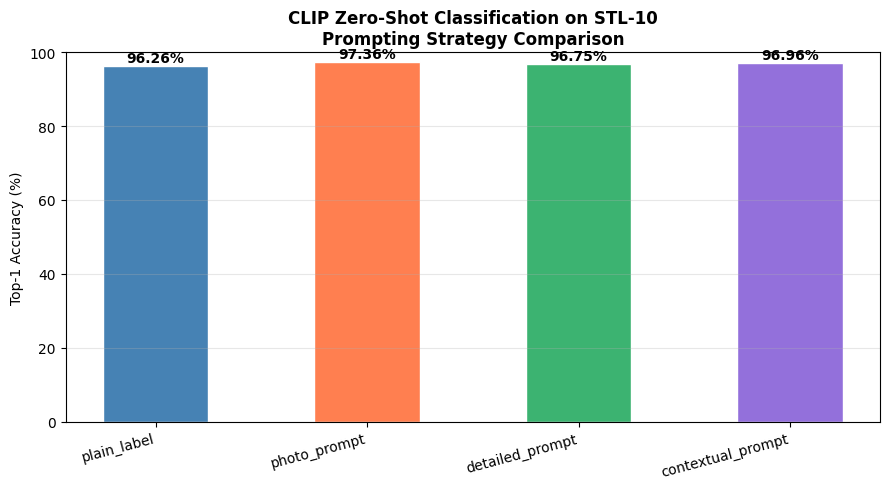

In [10]:
# ── 8. Plot comparison ────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

strategy_names = list(results.keys())
accuracies     = list(results.values())
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

bars = ax.bar(strategy_names, accuracies, color=colors, width=0.5, edgecolor='white')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('CLIP Zero-Shot Classification on STL-10\nPrompting Strategy Comparison',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(strategy_names, rotation=15, ha='right')

plt.tight_layout()
plt.savefig('task3_1_prompting_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── 9. Per-class breakdown for best strategy ──────────────────────────────────

best_strategy = max(results, key=results.get)
print(f"\nBest strategy: {best_strategy} ({results[best_strategy]:.2f}%)")
print("\nPer-class accuracy for best strategy:")

best_text_features = encode_text_prompts(
    model_clip, STL10_CLASSES, prompting_strategies[best_strategy], device
)
similarity   = image_features @ best_text_features.T.cpu()
predictions  = similarity.argmax(dim=-1)

print(f"\n{'Class':<12} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 42)
for cls_idx, cls_name in enumerate(STL10_CLASSES):
    mask    = true_labels == cls_idx
    correct = (predictions[mask] == cls_idx).sum().item()
    total   = mask.sum().item()
    acc     = 100.0 * correct / total
    print(f"{cls_name:<12} {correct:>8} {total:>8} {acc:>9.1f}%")


Best strategy: photo_prompt (97.36%)

Per-class accuracy for best strategy:
  Example prompt: 'a photo of a airplane'

Class         Correct    Total   Accuracy
------------------------------------------
airplane          787      800      98.4%
bird              798      800      99.8%
car               777      800      97.1%
cat               717      800      89.6%
deer              778      800      97.2%
dog               774      800      96.8%
horse             794      800      99.2%
monkey            776      800      97.0%
ship              799      800      99.9%
truck             789      800      98.6%


3.2: Exploring the Modality Gap

In [12]:
import umap
from sklearn.preprocessing import StandardScaler

In [13]:

# ── 1. Select a subset of STL-10 samples ─────────────────────────────────────

N_SAMPLES = 100   # 10 per class for a balanced visualization

# Load without transform first to get indices per class
stl10_raw = torchvision.datasets.STL10(
    root='./data', split='test', download=False
)

# Pick 10 images per class
selected_indices = []
class_counts = {i: 0 for i in range(10)}

for idx, (_, label) in enumerate(stl10_raw):
    if class_counts[label] < 10:
        selected_indices.append(idx)
        class_counts[label] += 1
    if len(selected_indices) == N_SAMPLES:
        break

# Reload with CLIP transform and subset
stl10_clip = torchvision.datasets.STL10(
    root='./data', split='test', download=False, transform=preprocess_clip
)
subset = torch.utils.data.Subset(stl10_clip, selected_indices)
subset_loader = DataLoader(subset, batch_size=32, shuffle=False, num_workers=2)

print(f"Selected {len(selected_indices)} samples ({N_SAMPLES//10} per class)")

Selected 100 samples (10 per class)


In [14]:
# ── 2. Extract image embeddings ───────────────────────────────────────────────

img_features_subset = []
img_labels_subset   = []

model_clip.eval()
with torch.no_grad():
    for imgs, labels in tqdm(subset_loader, desc='Encoding images'):
        imgs = imgs.to(device)
        feats = model_clip.encode_image(imgs)
        img_features_subset.append(feats.cpu())
        img_labels_subset.append(labels)

img_features_subset = torch.cat(img_features_subset).numpy()   # (100, 512)
img_labels_subset   = torch.cat(img_labels_subset).numpy()     # (100,)
print(f"Image embeddings: {img_features_subset.shape}")

Encoding images: 100%|██████████| 4/4 [00:00<00:00,  7.33it/s]

Image embeddings: (100, 512)


In [15]:
# ── 3. Extract text embeddings ────────────────────────────────────────────────
# One text embedding per class using photo_prompt (best strategy from 3.1)
# Then replicate to match the 100 image labels for plotting

text_prompts = [f"a photo of a {c}" for c in STL10_CLASSES]
tokens = clip.tokenize(text_prompts).to(device)

with torch.no_grad():
    text_features_subset = model_clip.encode_text(tokens).cpu().numpy()  # (10, 512)

# Replicate text embeddings to match image labels
# i.e. for each image, grab the text embedding of its class
text_features_matched = text_features_subset[img_labels_subset]   # (100, 512)
print(f"Text embeddings : {text_features_matched.shape}")

Text embeddings : (100, 512)


In [16]:
# ── 4. Visualize raw embeddings (before normalization) ────────────────────────

def plot_modality_gap(img_feats, txt_feats, labels, title, filename):
    """
    Project image and text embeddings jointly to 2D using UMAP
    and plot both modalities colored by class.
    """
    # Stack image and text features together for joint projection
    combined = np.concatenate([img_feats, txt_feats], axis=0)  # (200, 512)

    # UMAP projection
    reducer = umap.UMAP(n_components=2, random_state=42,
                        n_neighbors=15, min_dist=0.1)
    embedded = reducer.fit_transform(combined)   # (200, 2)

    img_embedded  = embedded[:N_SAMPLES]         # first 100 = images
    text_embedded = embedded[N_SAMPLES:]         # last  100 = text

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for cls_idx, cls_name in enumerate(STL10_CLASSES):
        mask = labels == cls_idx

        # Images — circles
        ax.scatter(img_embedded[mask, 0], img_embedded[mask, 1],
                   c=[colors[cls_idx]], marker='o', s=60,
                   alpha=0.8, label=f'{cls_name} (img)')

        # Text — stars
        ax.scatter(text_embedded[mask, 0], text_embedded[mask, 1],
                   c=[colors[cls_idx]], marker='*', s=200,
                   alpha=1.0, edgecolors='black', linewidths=0.5)

    # Legend — one entry per class only
    handles, lbls = ax.get_legend_handles_labels()
    # Take every other entry to avoid duplicate legend items
    ax.legend(handles[::1][:10], STL10_CLASSES,
              markerscale=1.2, bbox_to_anchor=(1.05, 1),
              loc='upper left', fontsize=8)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.text(0.02, 0.02, 'circles = images   stars = text',
            transform=ax.transAxes, fontsize=9, alpha=0.7)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


Plotting raw (unnormalized) embeddings...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


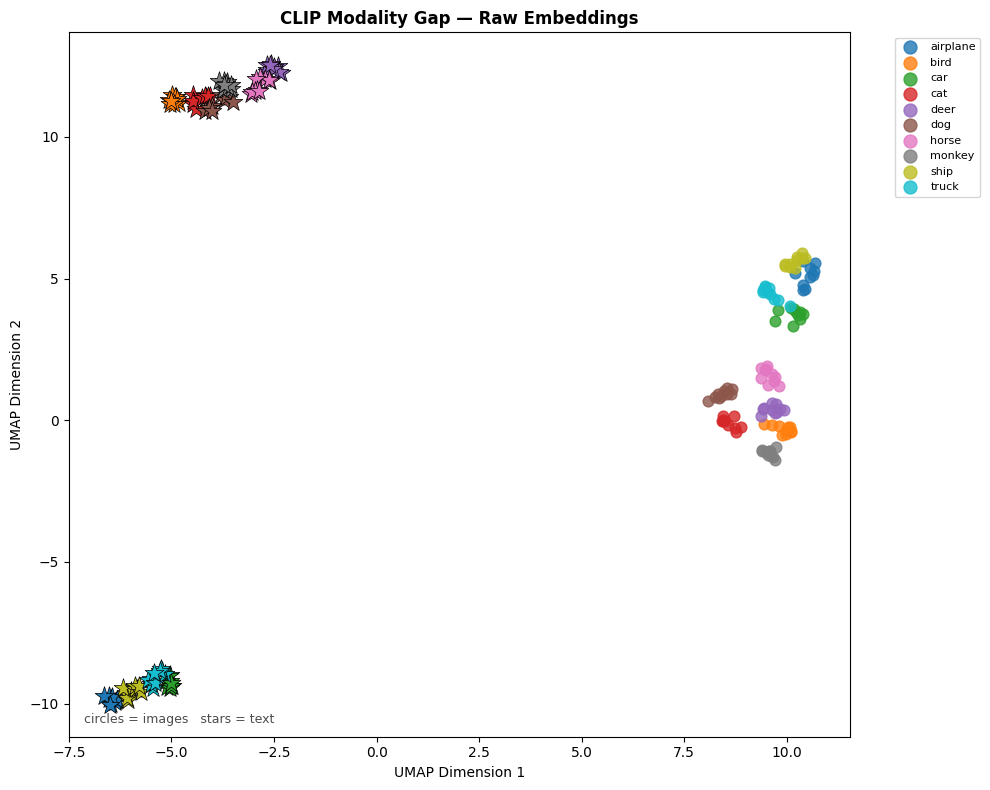

In [17]:
# ── 5. Plot 1 — Raw (unnormalized) embeddings ─────────────────────────────────
print("\nPlotting raw (unnormalized) embeddings...")
plot_modality_gap(
    img_features_subset,
    text_features_matched,
    img_labels_subset,
    title='CLIP Modality Gap — Raw Embeddings',
    filename='task3_2_modality_gap_raw.png'
)


Plotting L2-normalized embeddings...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


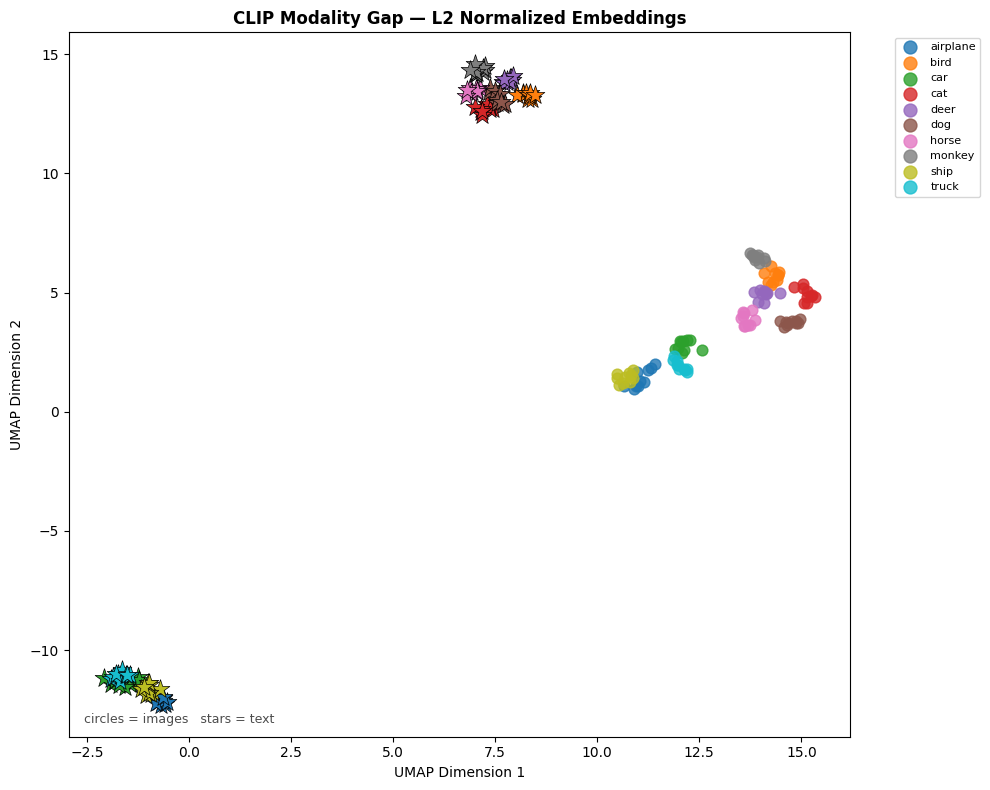

In [18]:
# ── 6. Plot 2 — L2 normalized embeddings ─────────────────────────────────────

def l2_normalize(x):
    return x / (np.linalg.norm(x, axis=-1, keepdims=True) + 1e-8)

img_norm  = l2_normalize(img_features_subset)
text_norm = l2_normalize(text_features_matched)

print("\nPlotting L2-normalized embeddings...")
plot_modality_gap(
    img_norm,
    text_norm,
    img_labels_subset,
    title='CLIP Modality Gap — L2 Normalized Embeddings',
    filename='task3_2_modality_gap_normalized.png'
)

In [19]:
# ── 7. Quantify the gap ───────────────────────────────────────────────────────
# Measure mean cosine similarity within modality vs across modalities

img_n  = torch.tensor(img_norm)
text_n = torch.tensor(text_norm)

# Cross-modal: cosine similarity between each image and its matching text
cross_modal_sim = (img_n * text_n).sum(dim=-1)   # (100,)

# Within image modality: mean pairwise similarity
img_img_sim = img_n @ img_n.T                     # (100, 100)
mask_diag   = ~torch.eye(100, dtype=torch.bool)
within_img_sim = img_img_sim[mask_diag].mean()

# Within text modality
txt_txt_sim     = text_n @ text_n.T
within_txt_sim  = txt_txt_sim[mask_diag].mean()

print("\n===== Modality Gap Quantification =====")
print(f"Mean cross-modal similarity  : {cross_modal_sim.mean():.4f}")
print(f"Mean within-image similarity : {within_img_sim:.4f}")
print(f"Mean within-text  similarity : {within_txt_sim:.4f}")
print(f"Modality gap (within - cross): "
      f"{((within_img_sim + within_txt_sim)/2 - cross_modal_sim.mean()):.4f}")


===== Modality Gap Quantification =====
Mean cross-modal similarity  : 0.2664
Mean within-image similarity : 0.6157
Mean within-text  similarity : 0.8706
Modality gap (within - cross): 0.4768


3.3: Bridging the Modality Gap

In [20]:
from scipy.linalg import orthogonal_procrustes

In [22]:
# ── 1. Get paired embeddings for Procrustes ───────────────────────────────────
# Procrustes needs paired points: X (images) aligned to Y (text)
# We use the full test set for a robust estimate of R

print("Extracting full test set embeddings for Procrustes alignment...")

# Image embeddings — already computed in 3.1 as image_features (N, 512)
# Normalized image features
img_full_norm = image_features / (
    torch.norm(image_features, dim=-1, keepdim=True) + 1e-8
)   # (N, 512)

# Text embeddings — one per class
text_class_prompts = [f"a photo of a {c}" for c in STL10_CLASSES]
tokens = clip.tokenize(text_class_prompts).to(device)
with torch.no_grad():
    text_class_features = model_clip.encode_text(tokens).cpu()   # (10, 512)
text_class_norm = text_class_features / (
    torch.norm(text_class_features, dim=-1, keepdim=True) + 1e-8
)   # (10, 512)

# For Procrustes we need paired (image, text) points of the same shape
# Match each image to its class text embedding
text_matched_full = text_class_norm[true_labels]   # (N, 512)

print(f"Image embeddings : {img_full_norm.shape}")
print(f"Text embeddings  : {text_matched_full.shape}")

Extracting full test set embeddings for Procrustes alignment...
Image embeddings : torch.Size([8000, 512])
Text embeddings  : torch.Size([8000, 512])


In [23]:
# ── 2. Learn Procrustes rotation matrix R ─────────────────────────────────────
# orthogonal_procrustes(A, B) finds R such that ||AR - B||_F is minimized
# A = image embeddings (source)
# B = text  embeddings (target)

X = img_full_norm.numpy()        # (N, 512) — source
Y = text_matched_full.numpy()    # (N, 512) — target

R, scale = orthogonal_procrustes(X, Y)

print(f"\nProcrustes rotation matrix R: {R.shape}")
print(f"Scale factor                : {scale:.4f}")


Procrustes rotation matrix R: (512, 512)
Scale factor                : 6894.4233


In [24]:
# ── 3. Apply rotation to image embeddings ─────────────────────────────────────
X_aligned = X @ R   # (N, 512) — rotated image embeddings

# Re-normalize after rotation
X_aligned_norm = X_aligned / (
    np.linalg.norm(X_aligned, axis=-1, keepdims=True) + 1e-8
)

print(f"Aligned image embeddings: {X_aligned_norm.shape}")

Aligned image embeddings: (8000, 512)



Plotting aligned embeddings...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


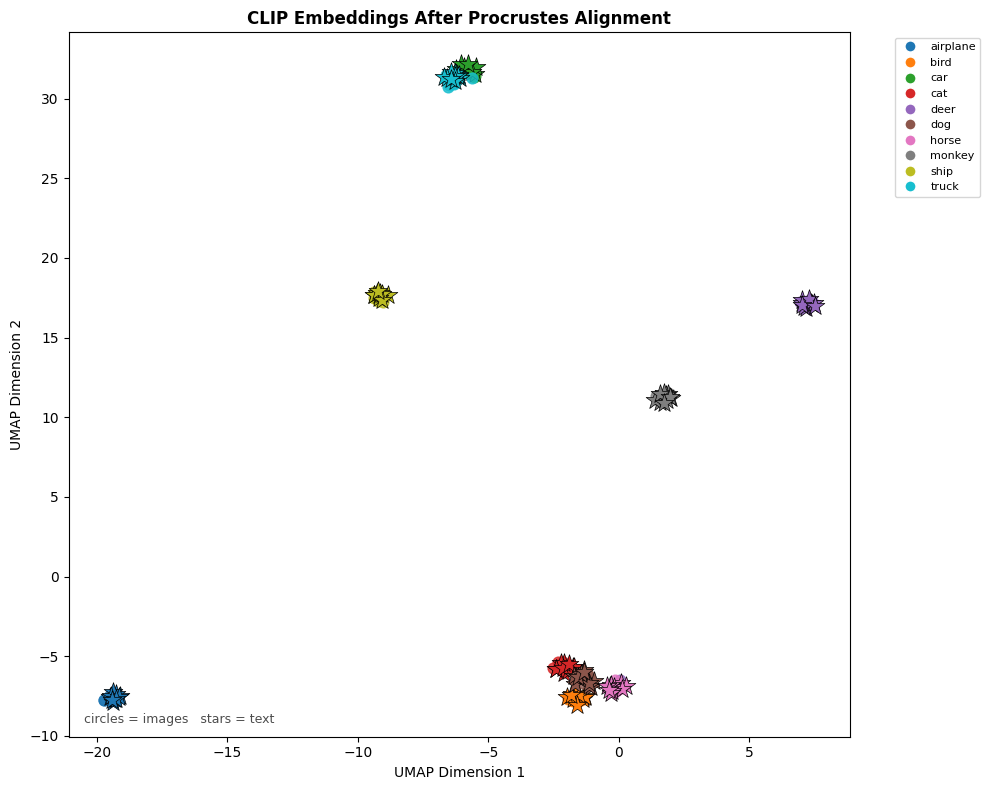

In [25]:
# ── 4. Visualize aligned embeddings with UMAP ─────────────────────────────────
def plot_aligned(img_feats, txt_feats, labels, title, filename):
    combined = np.concatenate([img_feats, txt_feats], axis=0)
    reducer  = umap.UMAP(n_components=2, random_state=42,
                         n_neighbors=15, min_dist=0.1)
    embedded = reducer.fit_transform(combined)

    n = len(img_feats)
    img_emb  = embedded[:n]
    text_emb = embedded[n:]

    fig, ax = plt.subplots(figsize=(10, 8))
    colors  = plt.cm.tab10(np.linspace(0, 1, 10))

    for cls_idx, cls_name in enumerate(STL10_CLASSES):
        mask = labels == cls_idx
        ax.scatter(img_emb[mask, 0],  img_emb[mask, 1],
                   c=[colors[cls_idx]], marker='o', s=60,
                   alpha=0.8)
        ax.scatter(text_emb[mask, 0], text_emb[mask, 1],
                   c=[colors[cls_idx]], marker='*', s=200,
                   alpha=1.0, edgecolors='black', linewidths=0.5)

    # Class legend
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=colors[i], markersize=8, label=STL10_CLASSES[i])
        for i in range(10)
    ]
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1),
              loc='upper left', fontsize=8)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.text(0.02, 0.02, 'circles = images   stars = text',
            transform=ax.transAxes, fontsize=9, alpha=0.7)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


# Use the subset from 3.2 for visualization (100 samples, balanced)
X_subset_aligned = X_aligned_norm[selected_indices]

print("\nPlotting aligned embeddings...")
plot_aligned(
    X_subset_aligned,
    text_norm,                # normalized text embeddings from 3.2
    img_labels_subset,
    title='CLIP Embeddings After Procrustes Alignment',
    filename='task3_3_aligned_embeddings.png'
)

In [26]:
# ── 5. Recompute classification accuracy with aligned embeddings ───────────────
# Compare original vs aligned accuracy across all four prompting strategies

print("\n===== Accuracy Comparison: Original vs Aligned =====")

results_aligned = {}
results_original = results.copy()   # from Task 3.1

for strategy_name, prompt_fn in prompting_strategies.items():
    # Text features for this strategy
    txt_feats = encode_text_prompts(
        model_clip, STL10_CLASSES, prompt_fn, device
    ).cpu().numpy()

    # Normalize text features
    txt_feats_norm = txt_feats / (
        np.linalg.norm(txt_feats, axis=-1, keepdims=True) + 1e-8
    )

    # Accuracy with aligned image embeddings
    sim_aligned  = X_aligned_norm @ txt_feats_norm.T   # (N, 10)
    preds_aligned = sim_aligned.argmax(axis=-1)
    acc_aligned   = 100.0 * (preds_aligned == true_labels.numpy()).mean()

    results_aligned[strategy_name] = acc_aligned


===== Accuracy Comparison: Original vs Aligned =====
  Example prompt: 'airplane'
  Example prompt: 'a photo of a airplane'
  Example prompt: 'a high-resolution photo of a airplane'
  Example prompt: 'a real-world photo of a airplane in its natural setting'


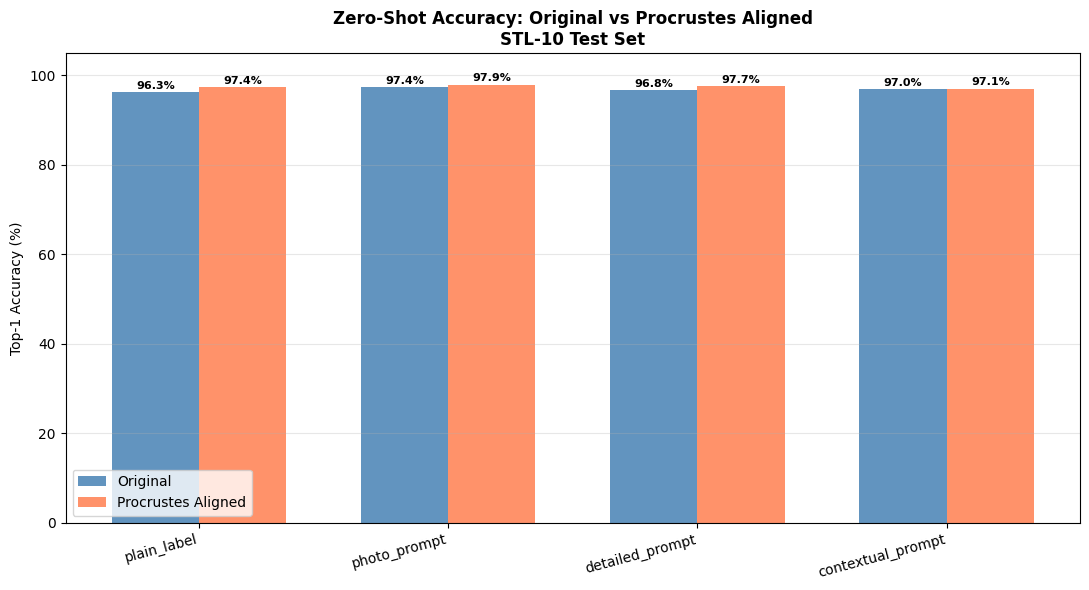

In [27]:
# ── 6. Plot comparison ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

x      = np.arange(len(prompting_strategies))
width  = 0.35
colors_orig    = 'steelblue'
colors_aligned = 'coral'

bars1 = ax.bar(x - width/2,
               [results_original[s] for s in prompting_strategies],
               width, label='Original', color=colors_orig, alpha=0.85)
bars2 = ax.bar(x + width/2,
               [results_aligned[s] for s in prompting_strategies],
               width, label='Procrustes Aligned', color=colors_aligned, alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(list(prompting_strategies.keys()), rotation=15, ha='right')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('Zero-Shot Accuracy: Original vs Procrustes Aligned\nSTL-10 Test Set',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('task3_3_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── 7. Summary table ──────────────────────────────────────────────────────────
print(f"\n{'Strategy':<20} {'Original':>12} {'Aligned':>12} {'Δ':>8}")
print("-" * 55)
for s in prompting_strategies:
    orig    = results_original[s]
    aligned = results_aligned[s]
    delta   = aligned - orig
    print(f"{s:<20} {orig:>11.2f}% {aligned:>11.2f}% {delta:>+7.2f}%")


Strategy                 Original      Aligned        Δ
-------------------------------------------------------
plain_label                96.26%       97.40%   +1.14%
photo_prompt               97.36%       97.91%   +0.55%
detailed_prompt            96.75%       97.66%   +0.91%
contextual_prompt          96.96%       97.09%   +0.12%


In [29]:
# ── 8. Quantify gap reduction after alignment ─────────────────────────────────
X_aligned_t    = torch.tensor(X_aligned_norm)
text_matched_t = torch.tensor(
    text_class_norm[true_labels].numpy()
)
text_matched_norm = text_matched_t / (
    torch.norm(text_matched_t, dim=-1, keepdim=True) + 1e-8
)

cross_modal_aligned = (X_aligned_t * text_matched_norm).sum(dim=-1).mean()

print(f"\n===== Gap Reduction =====")
print(f"Cross-modal similarity before alignment: "
      f"{(img_full_norm * text_matched_full).sum(dim=-1).mean():.4f}")
print(f"Cross-modal similarity after alignment : "
      f"{cross_modal_aligned:.4f}")


===== Gap Reduction =====
Cross-modal similarity before alignment: 0.2659
Cross-modal similarity after alignment : 0.8609
